<a href="https://colab.research.google.com/github/ManuJLV/PracticasIA/blob/main/KNeighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importamos las librerias a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, KFold

In [ ]:
uploaded = files.upload()

Saving drugs_norm.csv to drugs_norm.csv


In [ ]:
uploaded

{'drugs_norm.csv': b'"Cholesterolnorm","Age","Na","K","Sexnorm","BP","Drug"\r\n1,0.13559322033898305,0.738508715870943,0.1879998661446307,0,1.0,"drugY"\r\n1,0.5423728813559322,0.604061259904973,0.6098115985677475,1,0.0,"drugC"\r\n1,0.5423728813559322,0.4978693415040152,0.8185590469497709,1,0.0,"drugC"\r\n1,0.22033898305084745,0.1604321435157003,0.8745273232272531,0,0.5,"drugX"\r\n1,0.7796610169491526,0.14934817258460112,0.18364956664324197,0,0.0,"drugY"\r\n1,0.11864406779661017,0.44642031690861284,0.980908877957367,0,0.5,"drugX"\r\n1,0.576271186440678,0.7311884451876421,0.4767928253522069,0,0.5,"drugY"\r\n1,0.4406779661016949,0.6730860068655955,0.8272094501890707,1,0.0,"drugC"\r\n1,0.7627118644067796,0.6997855448650753,0.5221697955359234,1,0.5,"drugY"\r\n0,0.4745762711864407,0.06550606612492955,0.1194993809189171,1,0.0,"drugY"\r\n1,0.5423728813559322,1.0,0.9390790750593985,0,0.0,"drugC"\r\n0,0.3220338983050847,0.42336828438418045,0.24696315630960744,0,1.0,"drugY"\r\n1,0.474576271186440

In [ ]:
df = pd.read_csv(io.StringIO(uploaded['drugs_norm.csv'].decode('utf-8')))

In [ ]:
df

,Cholesterolnorm,Age,Na,K,Sexnorm,BP,Drug
0,1,0.135593,0.738509,0.188000,0,1.0,drugY
1,1,0.542373,0.604061,0.609812,1,0.0,drugC
2,1,0.542373,0.497869,0.818559,1,0.0,drugC
3,1,0.220339,0.160432,0.874527,0,0.5,drugX
4,1,0.779661,0.149348,0.183650,0,0.0,drugY
...,...,...,...,...,...,...,...
195,1,0.694915,0.880567,0.892782,0,0.0,drugC
196,1,0.016949,0.613438,0.700465,1,0.0,drugC
197,1,0.627119,0.125733,0.594970,1,0.5,drugX
198,0,0.135593,0.718263,0.601295,1,0.5,drugX


In [ ]:
#K-NN básico con Training-Testing

In [ ]:
#Seleccionar las variables predictoras y cuál es la variable objetivo o traget o label
X = df.drop('Drug', axis=1)
y = df['Drug']

In [ ]:
#Dividimos los datos en conjunto de entrenamiento y de prueba. 70% 30%
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Crear el clasificador Knn y lo vamos a entrenar
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Hacer las predicciones sobre el conjunto de prueba
y_pred = knn.predict(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

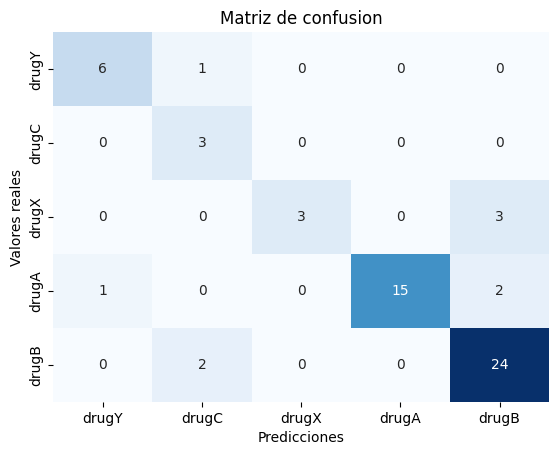

In [ ]:
#Crear matriz de confusion y verla gráficamente usando seaborn
etiquetas = list(df['Drug'].unique())
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas, cbar = False)
plt.title("Matriz de confusion")
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show


In [ ]:
#Calcular el accuracy general del modelo y un reporte de la clasificación
accuracy = accuracy_score(Y_test, y_pred)
print("Exactitud:", accuracy)

Exactitud: 0.85


In [ ]:
#Knn con validación cruzada versión 1
X = df.drop('Drug', axis=1)
Y = df['Drug']

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
#Aplicar validacipon cruzada K-fold con k=5
scores = cross_val_score(knn, X, Y, cv=5)

In [ ]:
print("Scores de cada fold: ", scores)
print("Accuracy promedio: ", scores.mean())

Scores de cada fold:  [0.75  0.85  0.85  0.675 0.8  ]
Accuracy promedio:  0.7849999999999999


In [ ]:
#Knn con validación cruzada version 2
#Seleccionar las variables predictorias y la variable objetivo
X = df.drop('Drug', axis=1)
Y = df['Drug']

In [ ]:
#Definir el numero de folds o pliegues para hacer la validacion cruzada
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
#Crear dos listas para almacenar las etiquetas reales y las predichas
all_y_test = []
all_y_pred = []

In [ ]:
#Realizamos la validación cruzada
scores = cross_val_score(knn, X, Y, cv=k_fold)

Accuracy para el fold: 0.78


<function matplotlib.pyplot.show(close=None, block=None)>

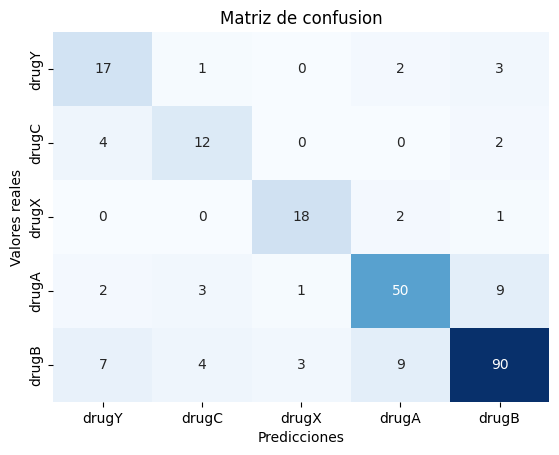

In [ ]:
#Realizamos la validación cruzada en que va en el for: se divide el conjunto de datos en indices de entrenamiento train_index e indices de prueba de test_index
#oara cada uno de los cinco folds
for train_index, test_index in k_fold.split(X):
  #Seleccionar los datos de entrenamiento y prueba para el fold actual
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]
#Entrenar el modelo en el conjunto de entrenamiento
knn.fit(X_train, Y_train)
#Hacer predicciones en el conjunto de prueba
y_pred = knn.predict(X_test)
#Almacenar las etiquetas reales y las predichas en las listas correspondientes
all_y_test.extend(Y_test)
all_y_pred.extend(y_pred)
#Calcular el accuracy para el fold actual
accuracy = accuracy_score(all_y_test, all_y_pred)
print(f"Accuracy para el fold: {accuracy:.2f}")
#Generar la matriz de confusion
etiquetas = list(Y.unique())
cm = confusion_matrix(all_y_test, all_y_pred)
#Mostrar la matriz de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas, cbar = False)
plt.title("Matriz de confusion")
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show

In [ ]:
#Version 3
from sklearn.model_selection import cross_val_score, KFold
X = df.drop('Drug', axis=1)
Y = df['Drug']
knn = KNeighborsClassifier(n_neighbors=3)
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(knn, X, Y, cv=k_fold)
#Mostrar los resultados
print("Scores de cada fold: ", scores)
print("Accuracy promedio: ", scores.mean())

Scores de cada fold:  [0.9  0.85 0.7  0.7  0.85]
Accuracy promedio:  0.8
